# A TinyVLM v3 using BitNet b1.58(W1.58A8)


In [ ]:
# If you saved your files in the drive, you can use this code to load them here
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


## 1. Installation

In [ ]:
# ==============================================================================
# 1  INSTALLATION

import subprocess, sys

def _pip(*p): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *p])

_pip("transformers>=4.40", "tokenizers>=0.15", "Pillow", "tqdm", "matplotlib", "psutil", "ninja")

print("Dependencies installed")



Dependencies installed


In [ ]:


# Needs: checkpoints in /content/tinyvlm3/ckpt/
# Needs: /content/tinyvlm3/tokenizer.json
# Needs: /content/tinyvlm3/clip_features.pt

import os, gc, time, statistics
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from tokenizers import Tokenizer
import psutil
import os, math, json, random, time, zipfile, textwrap, gc
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import torchvision.transforms as T
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as BLD
from transformers import CLIPModel
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import psutil
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LMCfg:
    vocab_size=8_192; max_seq_len=64; dim=1024; depth=12
    num_heads=16; mlp_ratio=4.0; dropout=0.1
    bitnet=True; bitnet_act_bits=8

class TrainCfg:
    root=Path('/content/tinyvlm3'); coco_dir=Path('/content/coco')

lcfg=LMCfg(); tcfg=TrainCfg(); CLIP_DIM=768

def vram_gb(k='alloc'):
    if device.type!='cuda': return 0.
    return (torch.cuda.memory_allocated() if k=='alloc' else torch.cuda.max_memory_allocated())/1024**3
def peak_reset():
    if device.type=='cuda': torch.cuda.reset_peak_memory_stats()
def rss_gb(): return psutil.Process(os.getpid()).memory_info().rss/1024**3


tokenizer = Tokenizer.from_file(str(tcfg.root/'tokenizer.json'))
lcfg.vocab_size = tokenizer.get_vocab_size()
BOS_ID = tokenizer.token_to_id('[BOS]')
EOS_ID = tokenizer.token_to_id('[EOS]')
PAD_ID = tokenizer.token_to_id('[PAD]')
def decode(ids): return tokenizer.decode([i for i in ids if i not in (BOS_ID,EOS_ID,PAD_ID)])


def _ste(x,dq): return x+(dq-x).detach()
def ternary_quant_w(w,eps=1e-5):
    s=w.detach().abs().mean().clamp_min(eps)
    return _ste(w, torch.clamp(torch.round(w/s),-1,1)*s)
def absmax_quant_a(x,bits=8,eps=1e-5):
    qmax=(2**(bits-1))-1; qmin=-(2**(bits-1))
    s=x.detach().abs().amax(dim=-1,keepdim=True).clamp_min(eps)/qmax
    return _ste(x, torch.clamp(torch.round(x/s),qmin,qmax)*s)

class BitLinear(nn.Module):
    def __init__(self,in_f,out_f,bias=False,act_bits=8,use_cuda_kernel=True,**kw):
        super().__init__()
        self.in_features=in_f; self.out_features=out_f; self.act_bits=act_bits
        self.weight=nn.Parameter(torch.empty(out_f,in_f))
        self.bias=nn.Parameter(torch.empty(out_f)) if bias else None
        nn.init.normal_(self.weight,std=0.02)
        if self.bias is not None: nn.init.zeros_(self.bias)
    def quantized_weight_int8(self):
        s=self.weight.detach().abs().mean().clamp_min(1e-5)
        q=torch.clamp(torch.round(self.weight.detach()/s),-1,1).to(torch.int8)
        return q.contiguous(), s.reshape(1).float()
    get_ternary_int8 = quantized_weight_int8
    def forward(self,x):
        return F.linear(absmax_quant_a(x,self.act_bits), ternary_quant_w(self.weight), self.bias)

def make_gpt_linear(cfg,in_d,out_d,bias=False):
    if getattr(cfg,'bitnet',False):
        return BitLinear(in_d,out_d,bias=bias,act_bits=getattr(cfg,'bitnet_act_bits',8))
    return nn.Linear(in_d,out_d,bias=bias)

class Projector(nn.Module):
    def __init__(self,in_d,out_d):
        super().__init__(); mid=out_d*2
        self.fc1=nn.Linear(in_d,mid); self.fc2=nn.Linear(mid,out_d)
        self.skip=nn.Linear(in_d,out_d,bias=False); self.norm=nn.LayerNorm(out_d); self.act=nn.GELU()
    def forward(self,x): return self.norm(self.fc2(self.act(self.fc1(x)))+self.skip(x))

class CausalSA(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.h=cfg.num_heads; self.d=cfg.dim//cfg.num_heads
        self.qkv=make_gpt_linear(cfg,cfg.dim,3*cfg.dim); self.proj=make_gpt_linear(cfg,cfg.dim,cfg.dim); self.drop=cfg.dropout
    def forward(self,x):
        B,T,D=x.shape; q,k,v=self.qkv(x).reshape(B,T,3,self.h,self.d).permute(2,0,3,1,4).unbind(0)
        return self.proj(F.scaled_dot_product_attention(q,k,v,is_causal=True,dropout_p=0.).transpose(1,2).reshape(B,T,D))

class CrossAttn(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.h=cfg.num_heads; self.d=cfg.dim//cfg.num_heads
        self.q=make_gpt_linear(cfg,cfg.dim,cfg.dim); self.kv=make_gpt_linear(cfg,cfg.dim,2*cfg.dim)
        self.proj=make_gpt_linear(cfg,cfg.dim,cfg.dim)
    def forward(self,x,ctx):
        B,T,D=x.shape; S=ctx.size(1)
        q=self.q(x).reshape(B,T,self.h,self.d).transpose(1,2)
        k,v=self.kv(ctx).reshape(B,S,2,self.h,self.d).permute(2,0,3,1,4).unbind(0)
        return self.proj(F.scaled_dot_product_attention(q,k,v).transpose(1,2).reshape(B,T,D))

class SwiGLU(nn.Module):
    def __init__(self,cfg):
        super().__init__(); h=int(cfg.dim*cfg.mlp_ratio)
        self.g=make_gpt_linear(cfg,cfg.dim,h); self.u=make_gpt_linear(cfg,cfg.dim,h)
        self.d=make_gpt_linear(cfg,h,cfg.dim); self.drop=nn.Dropout(cfg.dropout)
    def forward(self,x): return self.drop(self.d(F.silu(self.g(x))*self.u(x)))

class Block(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.n1=nn.LayerNorm(cfg.dim); self.sa=CausalSA(cfg)
        self.nc=nn.LayerNorm(cfg.dim); self.ca=CrossAttn(cfg)
        self.n2=nn.LayerNorm(cfg.dim); self.ff=SwiGLU(cfg)
    def forward(self,x,ctx=None):
        x=x+self.sa(self.n1(x))
        if ctx is not None: x=x+self.ca(self.nc(x),ctx)
        return x+self.ff(self.n2(x))

class TinyGPT(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.emb=nn.Embedding(cfg.vocab_size,cfg.dim); self.pos=nn.Embedding(cfg.max_seq_len,cfg.dim)
        self.drop=nn.Dropout(cfg.dropout)
        self.blocks=nn.ModuleList([Block(cfg) for _ in range(cfg.depth)])
        self.norm=nn.LayerNorm(cfg.dim)
        self.head=nn.Linear(cfg.dim,cfg.vocab_size,bias=False)
        self.head.weight=self.emb.weight
    def forward(self,ids,ctx=None):
        B,T=ids.shape; x=self.drop(self.emb(ids)+self.pos(torch.arange(T,device=ids.device)))
        for blk in self.blocks: x=blk(x,ctx)
        return self.head(self.norm(x))

class TinyVLM(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.proj=Projector(CLIP_DIM,cfg.dim); self.lm=TinyGPT(cfg)
    def encode(self,f): return self.proj(f.to(device=device,dtype=torch.float32))
    @torch.no_grad()
    def beam(self, clip_feat, width=5, max_new=55, len_pen=0.7):
        self.eval()
        img_feat = self.encode(clip_feat.unsqueeze(0) if clip_feat.dim()==2 else clip_feat)
        beams: List[Tuple[float,List[int]]] = [(0.0,[BOS_ID])]
        done:  List[Tuple[float,List[int]]] = []
        for _ in range(max_new):
            cands = []
            for score, seq in beams:
                if seq[-1] == EOS_ID: done.append((score,seq)); continue
                ids  = torch.tensor([seq], device=device)
                logp = F.log_softmax(self.lm(ids, img_feat)[:,-1,:], -1)
                tv, ti = torch.topk(logp, width)
                for v,i in zip(tv[0].tolist(), ti[0].tolist()):
                    cands.append((score+v, seq+[i]))
            if not cands: break
            cands.sort(key=lambda x: x[0]/(len(x[1])**len_pen), reverse=True)
            beams = cands[:width]
        done += beams
        best = max(done, key=lambda x: x[0]/(len(x[1])**len_pen))
        return decode(best[1][1:])
    @torch.no_grad()
    def generate(self, clip_feat, max_new=55, temperature=0.7, top_k=50, top_p=0.9):
        self.eval()
        img_feat = self.encode(clip_feat.unsqueeze(0) if clip_feat.dim()==2 else clip_feat)
        ids = torch.tensor([[BOS_ID]], device=device)
        for _ in range(max_new):
            if ids.size(1) >= lcfg.max_seq_len: break
            logits = self.lm(ids, img_feat)[:,-1,:] / temperature
            if top_k > 0:
                thr = torch.topk(logits, top_k).values[:,-1:]
                logits[logits < thr] = -float("inf")
            probs = F.softmax(logits, -1)
            sp, si = torch.sort(probs, descending=True)
            sp[sp.cumsum(-1) - sp > top_p] = 0.0
            sp = sp / sp.sum()
            next_id = si.gather(-1, torch.multinomial(sp, 1))
            if next_id.item() == EOS_ID: break
            ids = torch.cat([ids, next_id], dim=1)
        return decode(ids[0,1:].tolist())


# Kernel CUDA
from torch.utils.cpp_extension import load_inline
_CUDA = r'''
#include <torch/extension.h>
#include <c10/cuda/CUDAException.h>
__global__ void ternary_gemv(const int8_t* __restrict__ x_q,const uint8_t* __restrict__ W_pk,
    float xs,float ws,float* __restrict__ y,int K,int N){
    int n=blockIdx.x*blockDim.y+threadIdx.y,lane=threadIdx.x;
    if(n>=N)return;
    int pk_K=K>>2; const uint8_t* w_row=W_pk+(long)n*pk_K; int32_t acc=0;
    for(int pk=lane;pk<pk_K;pk+=32){uint8_t byte=w_row[pk];
        #pragma unroll
        for(int j=0;j<4;++j){int8_t xv=x_q[pk*4+j];uint8_t c=(byte>>(j*2))&0x3;
            if(c==2)acc+=(int32_t)xv; else if(c==0)acc-=(int32_t)xv;}}
    #pragma unroll
    for(int o=16;o>0;o>>=1)acc+=__shfl_down_sync(0xffffffff,acc,o);
    if(lane==0)y[n]=(float)acc*xs*ws;}
torch::Tensor ternary_linear_forward(torch::Tensor x_q,torch::Tensor W_pk,
    torch::Tensor x_scale,float w_scale,int M,int K,int N){
    x_q=x_q.contiguous();W_pk=W_pk.contiguous();
    auto y=torch::empty({N},x_q.options().dtype(torch::kFloat32));
    int wpb=8,blocks=(N+wpb-1)/wpb;
    ternary_gemv<<<blocks,dim3(32,wpb)>>>(
        (const int8_t*)x_q.data_ptr<int8_t>(),(const uint8_t*)W_pk.data_ptr<uint8_t>(),
        x_scale.item<float>(),w_scale,y.data_ptr<float>(),K,N);
    C10_CUDA_KERNEL_LAUNCH_CHECK();return y.unsqueeze(0);}
'''
_CPP = r'''
#include <torch/extension.h>
torch::Tensor ternary_linear_forward(torch::Tensor x_q,torch::Tensor W_pk,
    torch::Tensor x_scale,float w_scale,int M,int K,int N);
'''
print('Compilando kernel... (~60s primera vez)')
_ext = load_inline(name='ternary_bench',cpp_sources=_CPP,cuda_sources=_CUDA,
                   functions=['ternary_linear_forward'],
                   extra_cuda_cflags=['-O3','--use_fast_math'],verbose=False)
print('Kernel OK')

# TernaryBitLinear and swap
def pack_ternary(q):
    codes=(q.to(torch.int16)+1).to(torch.uint8); N,K=codes.shape
    codes=codes.reshape(N,K//4,4).to(torch.int16)
    return (codes[:,:,0]|(codes[:,:,1]<<2)|(codes[:,:,2]<<4)|(codes[:,:,3]<<6)).to(torch.uint8).contiguous()

def unpack_ternary(packed):
    N,pK=packed.shape; p=packed.to(torch.int16)
    return torch.stack([p&0x3,(p>>2)&0x3,(p>>4)&0x3,(p>>6)&0x3],dim=2).reshape(N,pK*4).sub_(1).to(torch.int8)

class TernaryBitLinear(nn.Module):
    def __init__(self,in_f,out_f,bias=False,act_bits=8):
        super().__init__(); self.in_features=in_f; self.out_features=out_f; self.act_bits=act_bits
        self.register_buffer('W_pk',torch.zeros(out_f,in_f//4,dtype=torch.uint8))
        self.register_buffer('w_scale',torch.ones(1,dtype=torch.float32))
        self.bias=nn.Parameter(torch.zeros(out_f)) if bias else None
    @classmethod
    def from_shadow(cls,src):
        m=cls(src.in_features,src.out_features,bias=(src.bias is not None),act_bits=src.act_bits)
        q,scale=src.get_ternary_int8()
        m.W_pk.copy_(pack_ternary(q.cpu())); m.w_scale.copy_(scale.reshape(1).float())
        if src.bias is not None: m.bias.data.copy_(src.bias.data.float())
        return m
    def forward(self,x):
        shape=x.shape[:-1]; x2=x.reshape(-1,self.in_features); M,K=x2.shape; N=self.out_features
        qmax=127; x_f=x2.float()
        x_s=x_f.abs().amax(dim=-1).clamp_min_(1e-5)/qmax
        x_q=(x_f/x_s.unsqueeze(-1)).round_().clamp_(-128,127).to(torch.int8)
        if M==1:
            y=_ext.ternary_linear_forward(x_q.contiguous(),self.W_pk.contiguous(),x_s.contiguous(),self.w_scale.item(),1,K,N)
        else:
            W_i8=unpack_ternary(self.W_pk)
            y=x_q.float().mm(W_i8.float().t())*x_s.unsqueeze(-1)*self.w_scale.item()
        if self.bias is not None: y=y+self.bias.to(dtype=y.dtype)
        return y.to(x.dtype).reshape(*shape,N)
    def bytes_weights(self): return self.W_pk.numel()

def swap_to_ternary(mdl,verbose=True):
    replaced=0
    for name,module in list(mdl.lm.named_modules()):
        if not isinstance(module,BitLinear): continue
        parts=name.split('.'); parent=mdl.lm
        for part in parts[:-1]: parent=getattr(parent,part)
        setattr(parent,parts[-1],TernaryBitLinear.from_shadow(module).to(device)); replaced+=1
    if verbose: print(f'Swap OK: {replaced} BitLinear -> TernaryBitLinear')
    return mdl

# checkpoint and swap
_ckpts=sorted((tcfg.root/'ckpt').glob('step*.pt'))
assert _ckpts, f'No hay checkpoints en {tcfg.root}/ckpt'
CKPT_PATH=_ckpts[-1]; print(f'Checkpoint: {CKPT_PATH.name}')

model=TinyVLM(lcfg).to(device)
ckpt=torch.load(CKPT_PATH,map_location=device)
model.load_state_dict(ckpt['model']); model.eval()
print(f'Cargado step={ckpt["step"]}  loss={ckpt["loss"]:.4f}')

model=swap_to_ternary(model)
torch.cuda.empty_cache()
print(f'Listo. VRAM: {vram_gb():.2f} GB')

Compilando kernel... (~60s primera vez)
Kernel OK
Checkpoint: step007999.pt
Cargado step=7999  loss=0.1941
Swap OK: 96 BitLinear -> TernaryBitLinear
Listo. VRAM: 3.06 GB


In [ ]:
# ==============================================================================
# 5  BPE TOKENIZER FROM SCRATCH
# ==============================================================================

SPECIAL = ["[PAD]","[UNK]","[BOS]","[EOS]"]
TOK_PATH = tcfg.root/"tokenizer.json"

def train_tok(caps, vocab_size):
    tmp = Path("/tmp/caps.txt")
    tmp.write_text("\n".join(c.lower() for c in caps))
    tok     = Tokenizer(BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = ByteLevel(add_prefix_space=False)
    tok.decoder       = BLD()
    trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIAL,
                         min_frequency=2, show_progress=True)
    tok.train([str(tmp)], trainer)
    return tok

if TOK_PATH.exists():
    tokenizer = Tokenizer.from_file(str(TOK_PATH))
    print(f"Tokenizer loaded (vocab={tokenizer.get_vocab_size()})")
else:
    print("Training BPE tokenizer ...")
    tokenizer = train_tok([c for _,c in pairs], lcfg.vocab_size)
    tokenizer.save(str(TOK_PATH))
    print(f"Tokenizer saved (vocab={tokenizer.get_vocab_size()})")

lcfg.vocab_size = tokenizer.get_vocab_size()
PAD_ID = tokenizer.token_to_id("[PAD]")
BOS_ID = tokenizer.token_to_id("[BOS]")
EOS_ID = tokenizer.token_to_id("[EOS]")

def encode(text, max_len=lcfg.max_seq_len):
    ids = [BOS_ID] + tokenizer.encode(text.lower()).ids[:max_len-2] + [EOS_ID]
    return ids

def decode(ids):
    return tokenizer.decode([i for i in ids if i not in (BOS_ID,EOS_ID,PAD_ID)])

# BPE may alter spacing on certain tokens, so no hard assert here
t = "a cat sitting on a couch"
print(f"Tokenizer OK")
print(f"  original : '{t}'")
print(f"  decoded  : '{decode(encode(t))}'")

Tokenizer loaded (vocab=7626)
Tokenizer OK
  original : 'a cat sitting on a couch'
  decoded  : 'a cat sitting on a couch'


In [ ]:
# ==============================================================================
# 4  COCO val2017 DOWNLOAD
# ==============================================================================


URLS = {
    "val2017.zip":
        "http://images.cocodataset.org/zips/val2017.zip",
    "annotations_trainval2017.zip":
        "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
}

def _hook(c, bs, tot):
    pct = min(c*bs*100/tot, 100)
    print(f"\r  [{'#'*int(pct/2)+'-'*(50-int(pct/2))}] {pct:5.1f}%", end="", flush=True)

def download_coco():
    tcfg.coco_dir.mkdir(parents=True, exist_ok=True)
    for fname, url in URLS.items():
        fpath  = tcfg.coco_dir / fname
        marker = tcfg.coco_dir / fname.replace(".zip","_ok")
        if not fpath.exists():
            print(f"Downloading {fname}")
            urllib.request.urlretrieve(url, fpath, _hook); print()
        if not marker.exists():
            print(f"Extracting {fname} ...")
            with zipfile.ZipFile(fpath) as z: z.extractall(tcfg.coco_dir)
            marker.touch()
        else:
            print(f"Already downloaded: {fname}")

download_coco()

ann = tcfg.coco_dir/"annotations"/"captions_val2017.json"
with open(ann) as f: raw = json.load(f)

id2file = {i["id"]: i["file_name"] for i in raw["images"]}
id2caps: Dict[int,List[str]] = {}
for a in raw["annotations"]:
    id2caps.setdefault(a["image_id"],[]).append(a["caption"])

# one (image, caption) pair per annotation entry
pairs: List[Tuple[str,str]] = []
for iid, caps in id2caps.items():
    p = tcfg.coco_dir/"val2017"/id2file[iid]
    if p.exists():
        for c in caps:
            pairs.append((str(p), c.strip()))

random.shuffle(pairs)
split       = int(0.9*len(pairs))
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

print(f"Pairs: {len(pairs):,}  (train={len(train_pairs):,}  val={len(val_pairs):,})")

  [##################################################] 100.0%
Extracting val2017.zip ...
  [##################################################] 100.0%
Extracting annotations_trainval2017.zip ...
Pairs: 25,014  (train=22,512  val=2,502)


In [ ]:
# ==============================================================================
# 6  CLIP FEATURE CACHING
#    Runs once and saves one tensor per image to disk.
#    The training loop never touches CLIP again — only reads cached tensors.
#    This makes training 5-8x faster.
# ==============================================================================

CLIP_MEAN  = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD   = [0.26862954, 0.26130258, 0.27577711]
clip_tf    = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(CLIP_MEAN, CLIP_STD),
])

# single file ~750 MB fp16 (vs ~3 GB with individual files)
CACHE_FILE = tcfg.root / "clip_features.pt"

# remove cache folders from previous runs to free disk space
import shutil
for old in ["/content/tinyvlm_ckpt", "/content/tinyvlm2_ckpt",
            "/content/tinyvlm3/clip_cache"]:
    if Path(old).exists():
        shutil.rmtree(old, ignore_errors=True)
        print(f"Removed old cache folder: {old}")

# global dict: stem -> fp32 tensor in RAM (~750 MB fp16 -> 1.5 GB fp32)
feat_cache: Dict[str, torch.Tensor] = {}


def build_cache():
    global feat_cache

    unique_paths = list({p for p, _ in pairs})

    # if the cache file already exists, load it into RAM
    if CACHE_FILE.exists():
        print("Loading features into RAM ...")
        saved = torch.load(CACHE_FILE, map_location="cpu")
        feat_cache = {k: v.to(torch.float32) for k, v in saved.items()}
        print(f"Cache loaded — {len(feat_cache):,} images in RAM")
        return

    # first run: extract with CLIP and save everything to a single file
    print("Extracting CLIP features (runs once, ~3-5 min) ...")
    _clip = CLIPModel.from_pretrained(CLIP_ID).vision_model.to(device).eval()
    for p in _clip.parameters():
        p.requires_grad_(False)

    bs     = 64
    result = {}   # stem -> fp16 tensor

    with torch.no_grad():
        for i in tqdm(range(0, len(unique_paths), bs), desc="  CLIP encode"):
            batch = unique_paths[i:i+bs]
            imgs, stems = [], []
            for pp in batch:
                try:
                    imgs.append(clip_tf(Image.open(pp).convert("RGB")))
                    stems.append(Path(pp).stem)
                except Exception:
                    continue
            if not imgs:
                continue
            tensor = torch.stack(imgs).to(device)
            with torch.cuda.amp.autocast(enabled=True, dtype=torch.float16):
                feats = _clip(pixel_values=tensor).last_hidden_state[:, 1:, :]
            feats = feats.cpu().to(torch.float16)   # (B, 196, 768) fp16
            for stem, feat in zip(stems, feats):
                result[stem] = feat

    del _clip
    torch.cuda.empty_cache()

    print(f"Saving {len(result):,} features to {CACHE_FILE} ...")
    torch.save(result, CACHE_FILE)
    sz = CACHE_FILE.stat().st_size / 1e6
    print(f"Saved — {sz:.0f} MB  (single file)")

    # load into RAM as fp32
    feat_cache = {k: v.to(torch.float32) for k, v in result.items()}
    del result


build_cache()


def load_feat(img_path: str) -> Optional[torch.Tensor]:
    """Returns the (196, 768) fp32 feature from RAM. None if not found."""
    return feat_cache.get(Path(img_path).stem)


# sanity check
_f = load_feat(pairs[0][0])
assert _f is not None and _f.shape == (196, 768), f"Cache fail: shape={getattr(_f,'shape',None)}"
print(f"Cache verified — {len(feat_cache):,} images  shape={_f.shape}  dtype={_f.dtype}")
del _f

Loading features into RAM ...
Cache loaded — 5,000 images in RAM
Cache verified — 5,000 images  shape=torch.Size([196, 768])  dtype=torch.float32


## 14. Benchmark speed (only TinyGPT)


In [ ]:
import gc, time, statistics
torch.cuda.empty_cache(); gc.collect()

# VRAM based (with feat_cache and model ternary loaded)
vram_base = torch.cuda.memory_allocated()

# Context visual fixed (already encoded so it excludes CLIP+Projector from the benchmark)
ctx_fixed = model.encode(feat_cache[list(feat_cache.keys())[0]].unsqueeze(0).to(device))
ctx_fixed = ctx_fixed.detach()  # [1, 1, dim]

#  load shadow GPT only (no Projector, no CLIP)
_sh_gpt = TinyGPT(lcfg).to(device)
_sh_state = {k.replace('lm.',''):v for k,v in
             torch.load(CKPT_PATH, map_location=device)['model'].items()
             if k.startswith('lm.')}
_sh_gpt.load_state_dict(_sh_state); _sh_gpt.eval()
vram_shadow = torch.cuda.memory_allocated() - vram_base

# ── VRAM of GPT ternary
torch.cuda.empty_cache()
vram_before_tern = torch.cuda.memory_allocated()

_ = model.lm(torch.tensor([[BOS_ID]], device=device), ctx_fixed)
vram_tern = sum(
    t.numel()*t.element_size()
    for m in model.lm.modules() if isinstance(m, TernaryBitLinear)
    for t in list(m.buffers())
) + sum(
    p.numel()*p.element_size()
    for p in model.lm.parameters()
)

print(f"VRAM model shadow GPT  : {vram_shadow/1024**2:.1f} MB")
print(f"VRAM model ternario GPT: {vram_tern/1024**2:.1f} MB")
print(f"Ratio VRAM              : {vram_shadow/vram_tern:.2f}x less with ternary")

# Benchmark for only TinyGPT.forward (No CLIP or Projector)
def bench_gpt(gpt, ctx, n=30, warmup=5, label=''):
    gpt.eval()
    ids = torch.tensor([[BOS_ID]], device=device)  # M=1, GEMV path
    torch.cuda.synchronize(); times = []
    with torch.no_grad():
        for i in range(n + warmup):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = gpt(ids, ctx)
            torch.cuda.synchronize()
            if i >= warmup:
                times.append((time.perf_counter()-t0)*1000)
    print(f"  {label:<35s} p50={statistics.median(times):6.2f}ms  "
          f"mean={statistics.mean(times):6.2f}ms  "
          f"min={min(times):5.2f}ms")
    return statistics.median(times)

print("\n── Only TinyGPT.forward (M=1, un paso de decoding) ─────────────────────")
p_sh  = bench_gpt(_sh_gpt,    ctx_fixed, label='Shadow fp32 GPT')
p_ter = bench_gpt(model.lm,   ctx_fixed, label='TernaryBitLinear GPT')
print(f"\n  Speedup : {p_sh/p_ter:.2f}x")

del _sh_gpt; torch.cuda.empty_cache()

VRAM model shadow GPT  : 1992.8 MB
VRAM model ternario GPT: 90.3 MB
Ratio VRAM              : 22.06x less with ternary

── Only TinyGPT.forward (M=1, un paso de decoding) ─────────────────────
  Shadow fp32 GPT                     p50= 83.50ms  mean= 89.46ms  min=83.37ms
  TernaryBitLinear GPT                p50= 33.75ms  mean= 40.20ms  min=31.87ms

  Speedup : 2.47x


## 15. Benchmark full pipeline

In [ ]:
def bench(mdl, items, method='beam', n=12, warmup=4, label=''):
    mdl.eval(); gc.collect(); torch.cuda.empty_cache(); peak_reset()
    rng  = random.Random(99)
    runs = rng.sample(items, min(n+warmup, len(items)))
    times=[]; caps_eg=[]
    with torch.no_grad():
        for idx,(img_path,gt) in enumerate(runs):
            feat=feat_cache[Path(img_path).stem].unsqueeze(0)
            torch.cuda.synchronize()
            t0=time.perf_counter()
            cap=mdl.beam(feat) if method=='beam' else mdl.generate(feat,temperature=0.8)
            torch.cuda.synchronize()
            ms=(time.perf_counter()-t0)*1000
            if idx>=warmup:
                times.append(ms)
                if len(caps_eg)<2: caps_eg.append((Path(img_path).name,gt,cap))
    r=dict(label=label,method=method,
           p50=statistics.median(times),mean=statistics.mean(times),
           p10=sorted(times)[len(times)//10],
           p90=sorted(times)[-len(times)//10],
           peak_vram_mb=vram_gb('peak')*1024, caps=caps_eg)
    print(f'  {label:<38s} {method:>6s}  '
          f'p50={r["p50"]:7.1f}ms  mean={r["mean"]:7.1f}ms  '
          f'p10={r["p10"]:6.1f}  p90={r["p90"]:6.1f}  '
          f'peakVRAM={r["peak_vram_mb"]:5.0f}MiB')
    return r


import json as _json, random
from pathlib import Path

_ann = tcfg.coco_dir / 'annotations' / 'captions_val2017.json'
with open(_ann) as f: _raw = _json.load(f)
_id2file = {i['id']: i['file_name'] for i in _raw['images']}
_id2caps = {}
for a in _raw['annotations']: _id2caps.setdefault(a['image_id'],[]).append(a['caption'])
_pairs = []
for iid, caps in _id2caps.items():
    p = tcfg.coco_dir / 'val2017' / _id2file[iid]
    if p.exists():
        for c in caps: _pairs.append((str(p), c.strip()))
random.shuffle(_pairs)
_split = int(0.9 * len(_pairs))
val_items = [(p,c) for p,c in _pairs[_split:] if Path(p).stem in feat_cache]
print(f'val_items: {len(val_items):,} pairs')

# Load shadow model for comparison
# Note: observed speedups here will be marginal, as the dominant cost is the CLIP
# feature extraction stage. Nevertheless, the decoder latency comparison is included
# for completeness and to validate that the ternary kernel introduces no regression.
print('Loading shadow model (fp32) for comparison ...')
m_shadow = TinyVLM(lcfg).to(device)
m_shadow.load_state_dict(torch.load(CKPT_PATH, map_location=device)['model'])
m_shadow.eval()

res={}
print('\n-- BEAM SEARCH (width=5, max 55 tokens) --------------------------------')
res['sh_b']  = bench(m_shadow, val_items, 'beam',   label='Shadow BitLinear fp32')
res['ter_b'] = bench(model,    val_items, 'beam',   label='TernaryBitLinear 2-bit kernel')

print('\n-- SAMPLING (temperature=0.8) ------------------------------------------')
res['sh_s']  = bench(m_shadow, val_items, 'sample', label='Shadow BitLinear fp32')
res['ter_s'] = bench(model,    val_items, 'sample', label='TernaryBitLinear 2-bit kernel')

beam_su   = res['sh_b']['p50']  / res['ter_b']['p50']
sample_su = res['sh_s']['p50']  / res['ter_s']['p50']
print(f'\n  Speedup beam   : {beam_su:.2f}x  ({res["sh_b"]["p50"]:.0f}ms -> {res["ter_b"]["p50"]:.0f}ms)')
print(f'  Speedup sample : {sample_su:.2f}x  ({res["sh_s"]["p50"]:.0f}ms -> {res["ter_s"]["p50"]:.0f}ms)')

del m_shadow; torch.cuda.empty_cache()

val_items: 2,502 pairs
Loading shadow model (fp32) for comparison ...

-- BEAM SEARCH (width=5, max 55 tokens) --------------------------------
  Shadow BitLinear fp32                    beam  p50=16717.6ms  mean=14550.0ms  p10=6532.0  p90=19187.7  peakVRAM= 5192MiB
  TernaryBitLinear 2-bit kernel            beam  p50=15814.1ms  mean=13799.9ms  p10=6475.7  p90=18280.8  peakVRAM= 5165MiB

-- SAMPLING (temperature=0.8) ------------------------------------------
  Shadow BitLinear fp32                  sample  p50= 1087.1ms  mean= 1071.2ms  p10= 865.3  p90=1216.8  peakVRAM= 5191MiB
  TernaryBitLinear 2-bit kernel          sample  p50=  969.8ms  mean=  975.5ms  p10= 827.6  p90=1161.3  peakVRAM= 5163MiB

  Speedup beam   : 1.06x  (16718ms -> 15814ms)
  Speedup sample : 1.12x  (1087ms -> 970ms)


## 16. Inferencia visual

[1] GT    : A white kitchen sink filled with dishes and eating utensils.
     Beam  : a close up look down in a sink with some items.
     Sample: a close up look down in a sink with some items.

[2] GT    : A very pretty kitchen with a small wooden dining table.
     Beam  : a wooden table with two chairs next to a sink.
     Sample: a wooden table with two chairs next to a sink.

[3] GT    : Some giraffes are standing in the middle of the zoo exhibit.
     Beam  : giraffes inside of their habitat at a zoo
     Sample: giraffes inside of their habitat at a zoo

[4] GT    : Group of soccer players on field kicking ball.
     Beam  : the boys are playing soccer and they are running the ball
     Sample: a group of young boys playing soccer on s field.



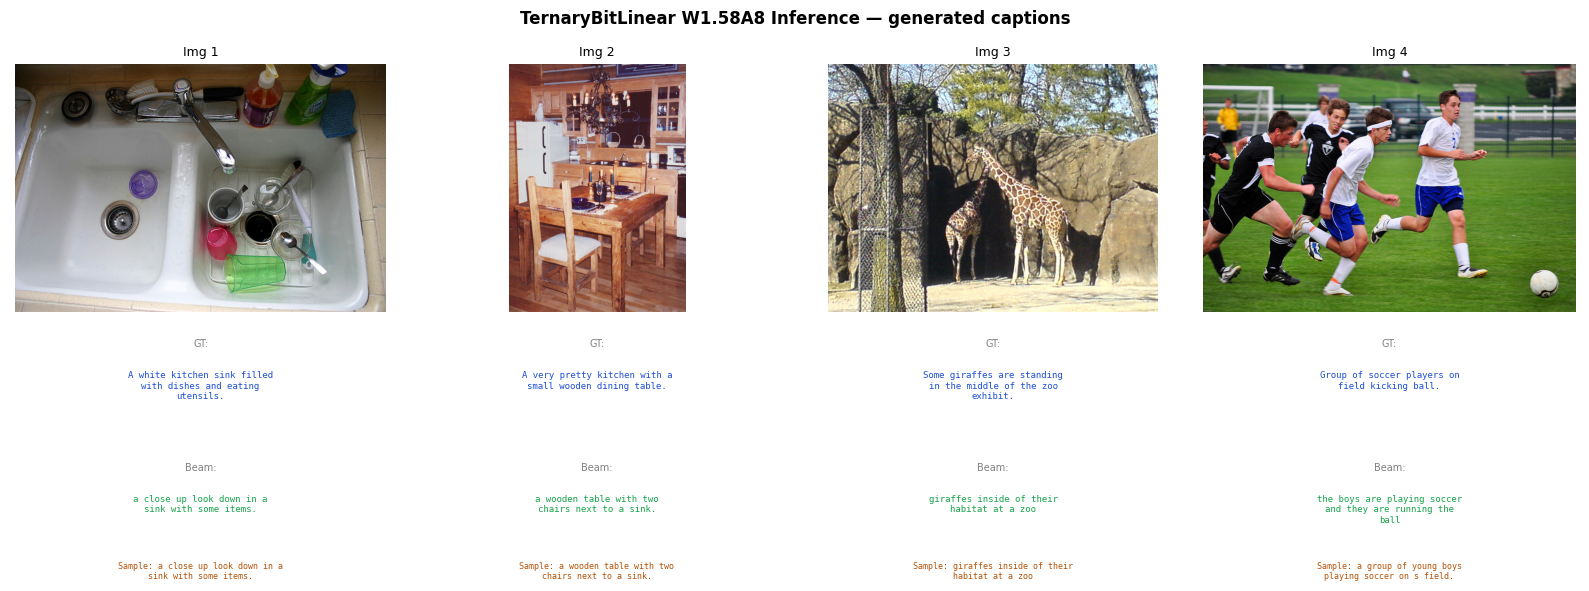

In [ ]:
# Inference test with the ternary model
import random
from PIL import Image
import matplotlib.pyplot as plt
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(42)
samples = random.sample(val_items, 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('TernaryBitLinear W1.58A8 Inference — generated captions', fontweight='bold')

model.eval()
with torch.no_grad():
    for i, (img_path, gt) in enumerate(samples):
        feat = feat_cache[Path(img_path).stem].unsqueeze(0)

        cap_beam   = model.beam(feat, width=5)
        cap_sample = model.generate(feat, temperature=0.8)

        ax_img = axes[0, i]
        ax_img.imshow(Image.open(img_path).convert('RGB'))
        ax_img.axis('off')
        ax_img.set_title(f'Img {i+1}', fontsize=9)

        ax_txt = axes[1, i]
        ax_txt.axis('off')
        ax_txt.text(0.5, 0.95, 'GT:', fontsize=7, color='gray',
                    ha='center', va='top', transform=ax_txt.transAxes)
        ax_txt.text(0.5, 0.82, '\n'.join(textwrap.wrap(gt[:80], 28)),
                    fontsize=6.5, color='#1D4ED8', ha='center', va='top',
                    transform=ax_txt.transAxes, family='monospace')
        ax_txt.text(0.5, 0.45, 'Beam:', fontsize=7, color='gray',
                    ha='center', va='top', transform=ax_txt.transAxes)
        ax_txt.text(0.5, 0.32, '\n'.join(textwrap.wrap(cap_beam[:80], 28)),
                    fontsize=6.5, color='#16A34A', ha='center', va='top',
                    transform=ax_txt.transAxes, family='monospace')
        ax_txt.text(0.5, 0.05, 'Sample: ' + '\n'.join(textwrap.wrap(cap_sample[:60], 28)),
                    fontsize=6, color='#B45309', ha='center', va='top',
                    transform=ax_txt.transAxes, family='monospace')

        print(f"[{i+1}] GT    : {gt[:70]}")
        print(f"     Beam  : {cap_beam}")
        print(f"     Sample: {cap_sample}\n")

plt.tight_layout()
plt.show()